# Calibrated Vol Surface Review

Load a calibration checkpoint, simulate MC paths, and compare the resulting model vol surface against market quotes.

In [6]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, torch, pickle, sys
from pathlib import Path
from scipy.stats import norm

sys.path.insert(0, '../..')
from pyquant.interest_rates import build_fwd_curve, build_ifwd_curve_from_now_starting
from ap.caplet_vol_surface import (
    fast_simulate, theta_to_vec, batch_price_caplets, rho_to_vec,
    generate_caplet_vol_surface, plot_caplet_vol_surface, check_market_arbitrage
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_val = lambda x: x.item() if isinstance(x, torch.Tensor) else float(x)

# ═══════════════════════════════════════════════════════════════
# CHECKPOINT SELECTION  —  change `ckpt_path` to load a different file
# ═══════════════════════════════════════════════════════════════
ckpt_path = Path('calibration_weights/fast_calibration_v8.pkl')   # <── CHANGE HERE
# ───────────────────────────────────────────────────────────────

print(f"Loading checkpoint: {ckpt_path}")
with open(ckpt_path, 'rb') as f:
    checkpoint = pickle.load(f)

# ── Market data & forward curves ──
data_dir = Path('../../../../data')
vol_key_rate = pd.read_csv(data_dir / 'volatility_key_rate.csv')
fwd_ois      = pd.read_csv(data_dir / 'forward_ois.csv')
fwd_key_rate = pd.read_csv(data_dir / 'forward_key_rate.csv')

_kr, _kt = [torch.tensor(fwd_key_rate[c].values, dtype=torch.float32) for c in ['forward_rate', 'time_to_maturity']]
_or, _ot = [torch.tensor(fwd_ois[c].values, dtype=torch.float32) for c in ['forward_rate', 'time_to_maturity']]

key_fwd_spline  = build_fwd_curve(_kr, _kt)
key_ifwd_spline = build_ifwd_curve_from_now_starting(_kr, _kt)
ois_ifwd_spline = build_ifwd_curve_from_now_starting(_or, _ot)

# ── Timeline (daily, 10Y) ──
T_MAX, N_STEPS = 10.0, 3651
timeline = torch.linspace(0, T_MAX, N_STEPS + 1, dtype=torch.float32, device=device)
dt = timeline[1] - timeline[0]
I_key = key_ifwd_spline.evaluate(timeline.cpu()).to(device)
I_ois = ois_ifwd_spline.evaluate(timeline.cpu()).to(device)
f_key_vec = torch.zeros_like(timeline); f_key_vec[:-1] = torch.diff(I_key) / dt; f_key_vec[-1] = f_key_vec[-2]
f_ois_vec = torch.zeros_like(timeline); f_ois_vec[:-1] = torch.diff(I_ois) / dt; f_ois_vec[-1] = f_ois_vec[-2]

# ── Caplet grid ──
caplet_data = vol_key_rate[['time_to_maturity', 'strike', 'implied_normal_vol']].values
T_fixes = torch.tensor(caplet_data[:, 0], dtype=torch.float32, device=device)
strikes  = torch.tensor(caplet_data[:, 1], dtype=torch.float32, device=device)
tau = 0.25
idx_fixes = torch.searchsorted(timeline, T_fixes).clamp(0, len(timeline)-1)
idx_pays  = torch.searchsorted(timeline, T_fixes + tau).clamp(0, len(timeline)-1)

# ── Build parameter dict from checkpoint ──
bp = {
    'theta': checkpoint['theta_values'].to(device),
    'v0': checkpoint['v0'], 'kappa': checkpoint['kappa'],
    'epsilon': checkpoint['epsilon'], 'lam': checkpoint['lam'],
    'gamma': checkpoint['gamma'], 'xi': checkpoint['xi'],
    'rho_1y': checkpoint.get('rho_1y', 0.0),
    'rho_5y': checkpoint.get('rho_5y', 0.0),
    'rho_10y': checkpoint.get('rho_10y', 0.0),
}
theta_nodes = checkpoint['theta_nodes'].to(device)
rho_nodes_t = torch.tensor([1.0, 5.0, 10.0], device=device)
rho_nodes_v = torch.tensor([_val(bp['rho_1y']), _val(bp['rho_5y']), _val(bp['rho_10y'])],
                           dtype=torch.float32, device=device)

theta_vec = theta_to_vec(bp['theta'], theta_nodes, timeline)
rho_vec   = rho_to_vec(rho_nodes_v, rho_nodes_t, timeline)

# ── MC simulation ──
key_paths, ois_paths, _ = fast_simulate(
    20000, timeline, theta_vec,
    _val(bp['epsilon']), _val(bp['v0']), _val(bp['kappa']),
    _val(bp['lam']), _val(bp['gamma']), _val(bp['xi']),
    f_key_vec, f_ois_vec, device, seed=12345, rho_vx=rho_vec
)
model_pvs, F_model, P_model = batch_price_caplets(
    key_paths, ois_paths, timeline, idx_fixes, idx_pays, strikes, tau, device
)

# ── Implied vol surface ──
vk_final = vol_key_rate.copy()
vk_final['pv_model_key'] = model_pvs.cpu().numpy()
vol_results, vol_rmse = generate_caplet_vol_surface(
    vk_final, fwd_key_rate, fwd_ois=fwd_ois, version_name="Fast",
    F_model=F_model.cpu().numpy(), P_model=P_model.cpu().numpy()
)

# ── Calibrated params summary ──
tc = bp['theta'].cpu().numpy()
print(f"\nCheckpoint: {ckpt_path.name}  |  iter={checkpoint.get('iteration', '?')}  |  loss={checkpoint.get('loss', '?'):.4e}")
print(f"  theta (√%) = [{', '.join(f'{np.sqrt(v)*100:.2f}' for v in tc)}]")
print(f"  v0={bp['v0']:.4f}  κ={bp['kappa']:.3f}  ε={bp['epsilon']:.3f}  λ={bp['lam']:.3f}  γ={bp['gamma']:.3f}  ξ={bp['xi']:.5f}")
print(f"  ρ(t) = [{_val(bp['rho_1y']):+.3f}, {_val(bp['rho_5y']):+.3f}, {_val(bp['rho_10y']):+.3f}]")
print(f"  Vol RMSE: {vol_rmse:.4f}")

Loading checkpoint: calibration_weights\fast_calibration_v8.pkl

FAST VOLATILITY SURFACE DIAGNOSTICS
Total caplets:        495
Valid vol inversions: 449 (90.7%)
Failed inversions:    46
Sub-intrinsic (conv): 0 (MC price < det. intrinsic → NaN)
Vol RMSE:             6.090%
Model vol range:      2.77% - 51.16%
Market vol range:     0.97% - 10.58%


Checkpoint: fast_calibration_v8.pkl  |  iter=300  |  loss=6.8721e-02
  theta (√%) = [2.77, 2.37, 1.15, 4.83, 3.87, 4.88]
  v0=0.0003  κ=1.679  ε=0.095  λ=0.290  γ=0.010  ξ=0.02364
  ρ(t) = [+0.000, +0.000, +0.000]
  Vol RMSE: 0.0609



Surface Coverage: 449/495 points (90.7%)
Missing 46 points due to inversion failures


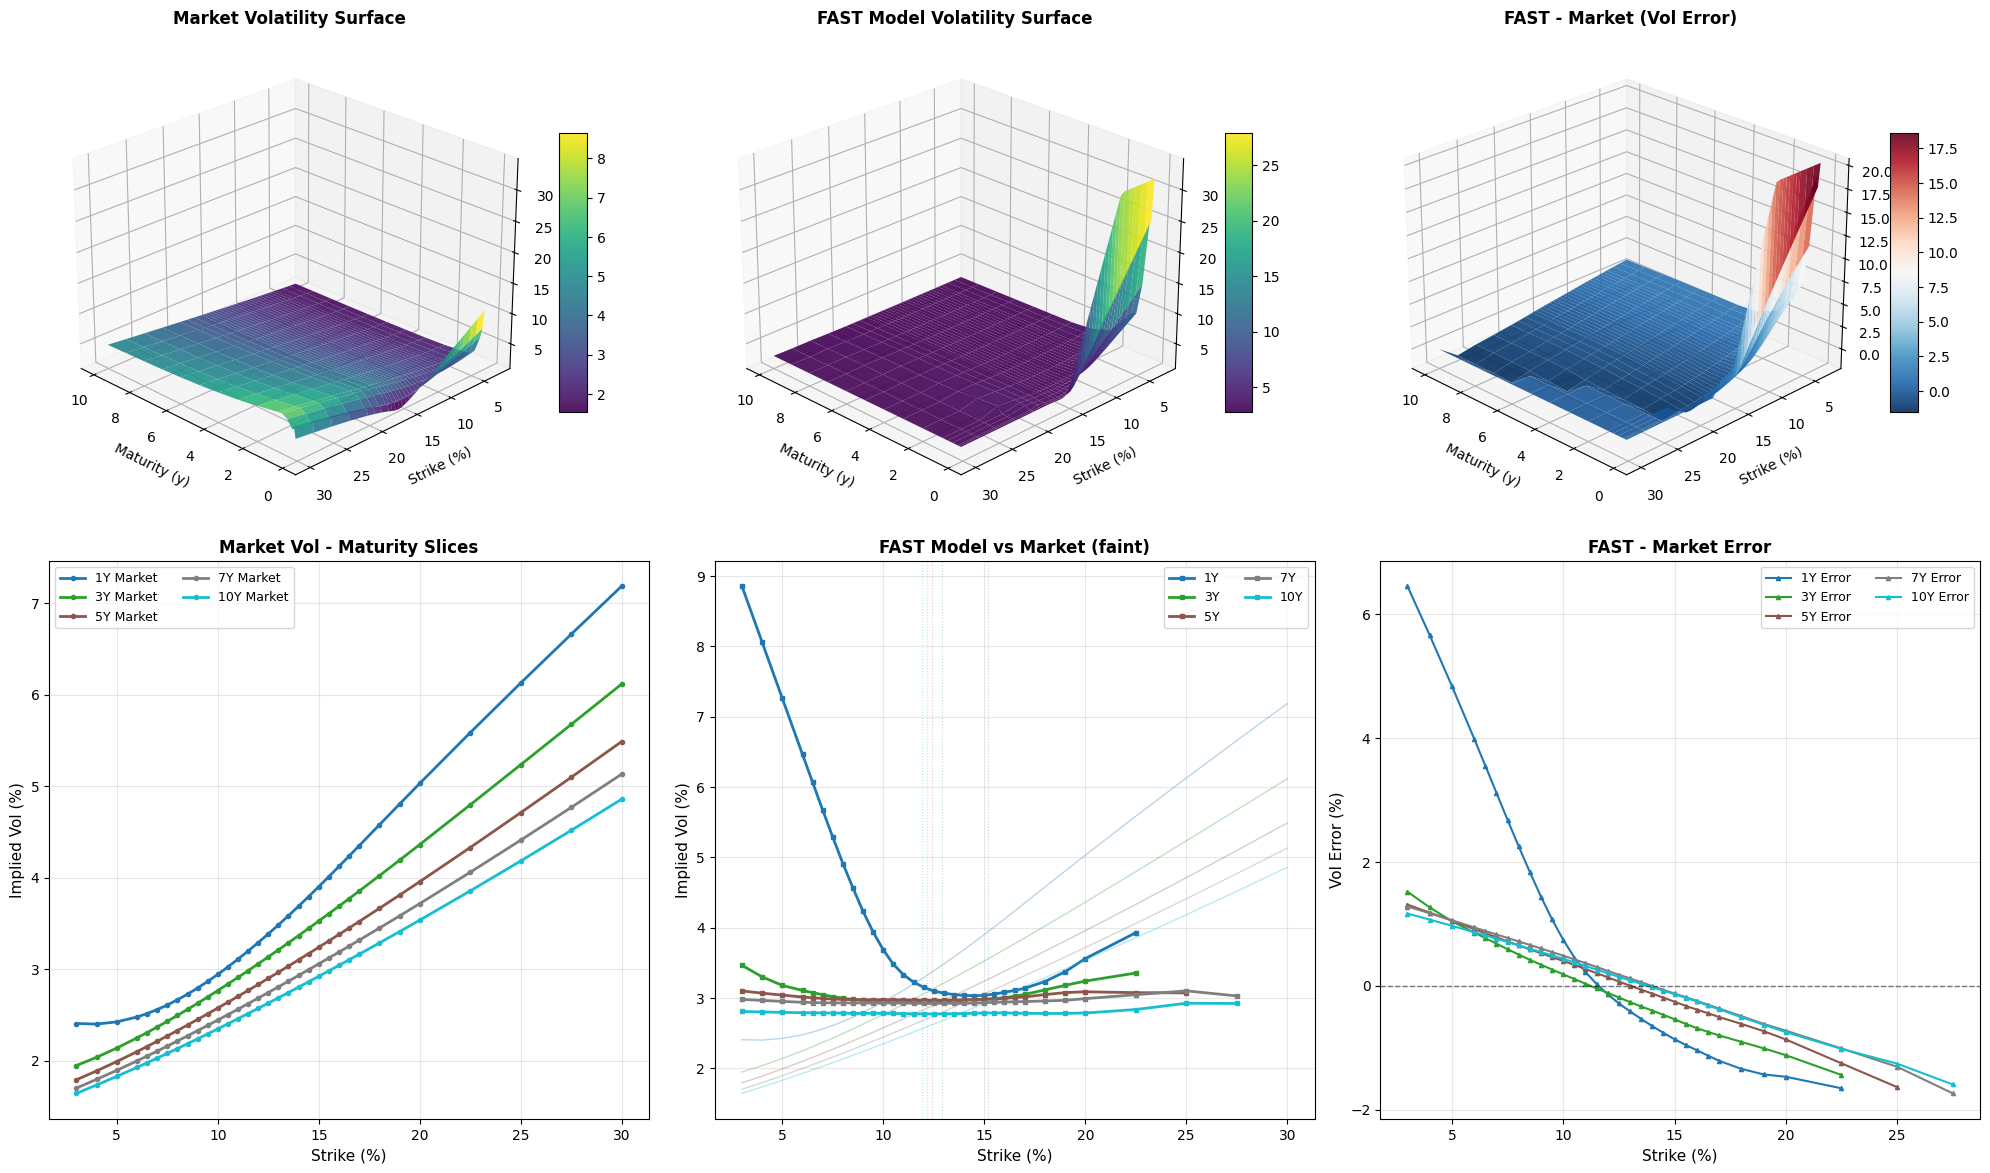

In [7]:
# ── Main vol surface plot (3D market/model/error + 2D slices) ──
plot_caplet_vol_surface(vol_results, version_name="Fast", fwd_key_rate=fwd_key_rate)

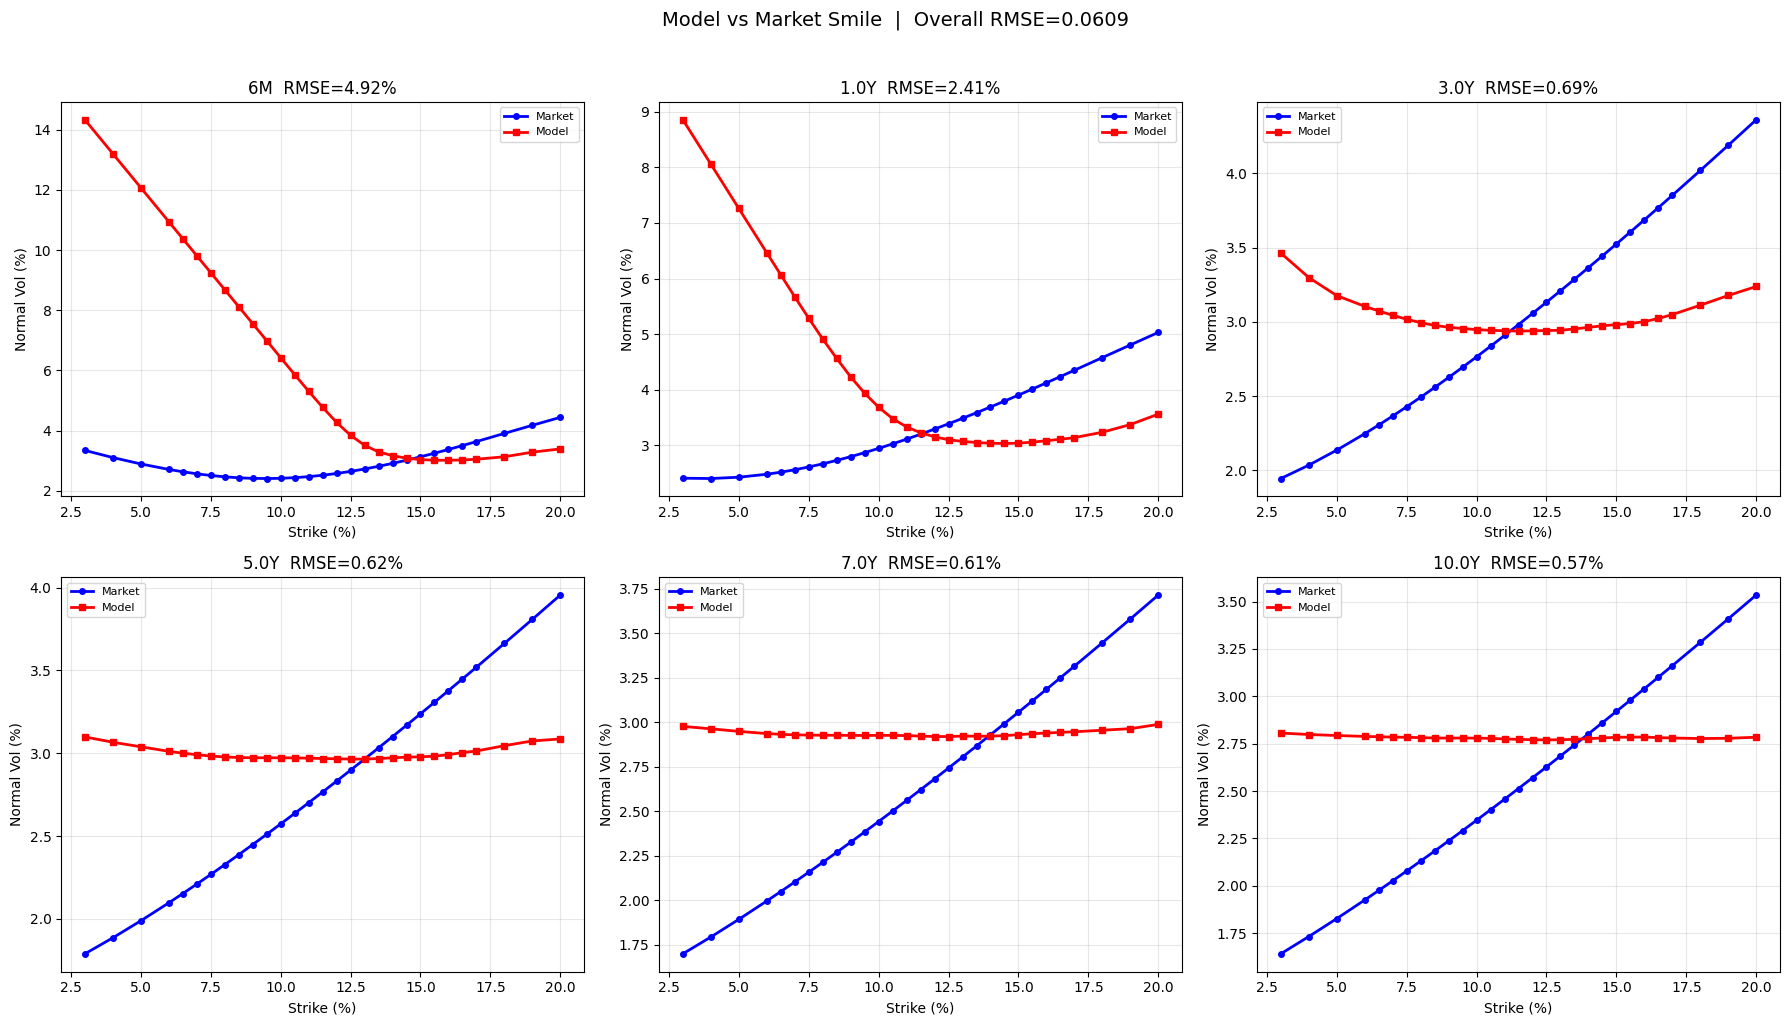

,n,RMSE,Bias,Mkt_skew,Mdl_skew
T,,,,,
1M,26,20.68%,+16.98%,-0.7279,-3.7113
2M,27,8.70%,+6.86%,-0.3631,-1.6480
3M,28,8.99%,+7.00%,-0.2321,-1.5152
6M,29,4.92%,+3.26%,+0.0789,-0.7089
9M,29,2.64%,+1.18%,+0.1643,-0.3351
1.0Y,29,2.41%,+0.90%,+0.1655,-0.2984
2.0Y,29,0.94%,+0.00%,+0.1572,-0.0437
3.0Y,29,0.69%,+0.01%,+0.1448,-0.0070
4.0Y,29,0.63%,+0.09%,+0.1361,-0.0010


In [8]:
# ── Vol smile slices: market vs model ──
mcol = [c for c in vol_results.columns if c.startswith('model_vol_')][0]
vr = vol_results.dropna(subset=[mcol]).query('strike <= 0.20').copy()
vr['mkt'], vr['mdl'] = vr['implied_normal_vol'] * 100, vr[mcol] * 100
vr['err'] = vr['mdl'] - vr['mkt']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, T in enumerate([0.5, 1.0, 3.0, 5.0, 7.0, 10.0]):
    ax = axes[i // 3, i % 3]
    sub = vr[np.abs(vr['time_to_maturity'] - T) < 0.02].sort_values('strike')
    if len(sub) == 0: continue
    lbl = f'{T:.1f}Y' if T >= 1 else f'{T*12:.0f}M'
    ax.plot(sub['strike']*100, sub['mkt'], 'b-o', ms=4, lw=2, label='Market')
    ax.plot(sub['strike']*100, sub['mdl'], 'r-s', ms=4, lw=2, label='Model')
    ax.set_title(f'{lbl}  RMSE={np.sqrt(np.mean(sub["err"]**2)):.2f}%')
    ax.set_xlabel('Strike (%)'); ax.set_ylabel('Normal Vol (%)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle(f'Model vs Market Smile  |  Overall RMSE={vol_rmse:.4f}', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# ── Summary by maturity ──
rows = []
for T in sorted(vr['time_to_maturity'].unique()):
    sub = vr[np.abs(vr['time_to_maturity'] - T) < 0.02]
    if len(sub) < 3: continue
    lbl = f'{T:.1f}Y' if T >= 1 else f'{T*12:.0f}M'
    rmse, bias = np.sqrt(np.mean(sub['err']**2)), sub['err'].mean()
    row = {'T': lbl, 'n': len(sub), 'RMSE': f'{rmse:.2f}%', 'Bias': f'{bias:+.2f}%'}
    if len(sub) >= 4:
        row['Mkt_skew'] = f"{np.polyfit(sub['strike']*100, sub['mkt'], 1)[0]:+.4f}"
        row['Mdl_skew'] = f"{np.polyfit(sub['strike']*100, sub['mdl'], 1)[0]:+.4f}"
    rows.append(row)
display(pd.DataFrame(rows).set_index('T'))

In [9]:
# ── Diff grid (model - market, % points) ──
vr2 = vol_results[vol_results['strike'] <= 0.20].copy()
vr2['diff'] = (vr2[mcol] - vr2['implied_normal_vol']) * 100
mats = sorted(vr2['time_to_maturity'].unique())
mat_lbl = {t: f'{t:.1f}Y' if t >= 1 else f'{t*12:.0f}M' for t in mats}

diff_grid = vr2.pivot(index='strike', columns='time_to_maturity', values='diff')
diff_grid.columns = [mat_lbl[c] for c in diff_grid.columns]
diff_grid.index = [f'{k*100:.1f}%' for k in diff_grid.index]

print("MODEL - MARKET (% points)")
with pd.option_context('display.float_format', '{:+.2f}'.format, 'display.max_columns', 20, 'display.width', 200):
    display(diff_grid)

MODEL - MARKET (% points)


,1M,2M,3M,6M,9M,1.0Y,2.0Y,3.0Y,4.0Y,5.0Y,6.0Y,7.0Y,8.0Y,9.0Y,10.0Y
3.0%,+40.58,+17.70,+18.68,+10.99,+6.70,+6.45,+2.47,+1.52,+1.30,+1.31,+1.29,+1.28,+1.24,+1.19,+1.17
4.0%,+37.44,+16.31,+17.21,+10.10,+5.99,+5.66,+1.97,+1.26,+1.16,+1.18,+1.18,+1.17,+1.13,+1.09,+1.07
5.0%,+34.29,+14.92,+15.73,+9.18,+5.25,+4.84,+1.51,+1.04,+1.01,+1.05,+1.06,+1.06,+1.02,+0.99,+0.97
6.0%,+31.15,+13.52,+14.25,+8.23,+4.47,+3.99,+1.14,+0.86,+0.86,+0.91,+0.94,+0.94,+0.91,+0.88,+0.86
6.5%,+29.58,+12.82,+13.50,+7.75,+4.06,+3.55,+0.96,+0.77,+0.79,+0.85,+0.88,+0.88,+0.86,+0.83,+0.81
7.0%,+28.01,+12.12,+12.76,+7.25,+3.65,+3.11,+0.81,+0.68,+0.71,+0.78,+0.81,+0.83,+0.80,+0.77,+0.76
7.5%,+26.43,+11.41,+12.01,+6.74,+3.22,+2.68,+0.67,+0.59,+0.64,+0.71,+0.75,+0.77,+0.75,+0.72,+0.71
8.0%,+24.86,+10.70,+11.25,+6.22,+2.80,+2.25,+0.54,+0.50,+0.56,+0.65,+0.70,+0.71,+0.69,+0.67,+0.65
8.5%,+23.29,+9.99,+10.50,+5.69,+2.37,+1.84,+0.43,+0.42,+0.49,+0.59,+0.64,+0.66,+0.64,+0.61,+0.60
9.0%,+21.71,+9.27,+9.73,+5.14,+1.94,+1.44,+0.31,+0.34,+0.42,+0.52,+0.58,+0.60,+0.58,+0.55,+0.54



MARKET SURFACE ARBITRAGE ANALYSIS

ARBITRAGE CONDITIONS:
  Points checked:      495
  Arbitrage-free:      450 (90.9%)
  Calendar violations: 28 (dw/dT < 0)
  Butterfly violations:17 (d²C/dK² < 0)

LOCAL VOL COMPUTABILITY:
  Computable (σ_loc² > 0): 415/495 (83.8%)
  Failures breakdown:
    d²C/dK² ≈ 0:           54 (gamma vanishes at deep ITM/OTM)
    dC/dT < 0:             26 (price derivative negative)
    local_var ≤ 0:         26 (dC/dT and d²C/dK² opposite signs)

  NOTE: 35 points are ARBITRAGE-FREE but local vol undefined.
  This is theoretically expected (Gatheral-Jacquier 2014):
  - Calendar arb uses total variance: dw/dT ≥ 0 where w = σ²T
  - Local vol uses price derivative: σ²_loc = (dC/dT) / (0.5 d²C/dK²)
  - dw/dT ≥ 0 does NOT imply dC/dT > 0 (nonlinear relationship)

  ⚠ Surface has ARBITRAGE VIOLATIONS

  Calendar arbitrage locations (dw/dT < 0, w = σ²T):
       T  K_% dw_dT_fmt
0.166667  3.0 -8.48e-04
0.166667  4.0 -6.99e-04
0.166667  5.0 -5.59e-04
0.166667  6.0 -4.27

c:\Personal\Education\MSc - PHDs\MIPT\Final paper\noa\docs\quant\ap\multi_theta\../..\ap\caplet_vol_surface.py:491: RuntimeWarning: invalid value encountered in sqrt
  local_vol_matrix = np.where(local_var_matrix > 0, np.sqrt(local_var_matrix) * 100, np.nan)


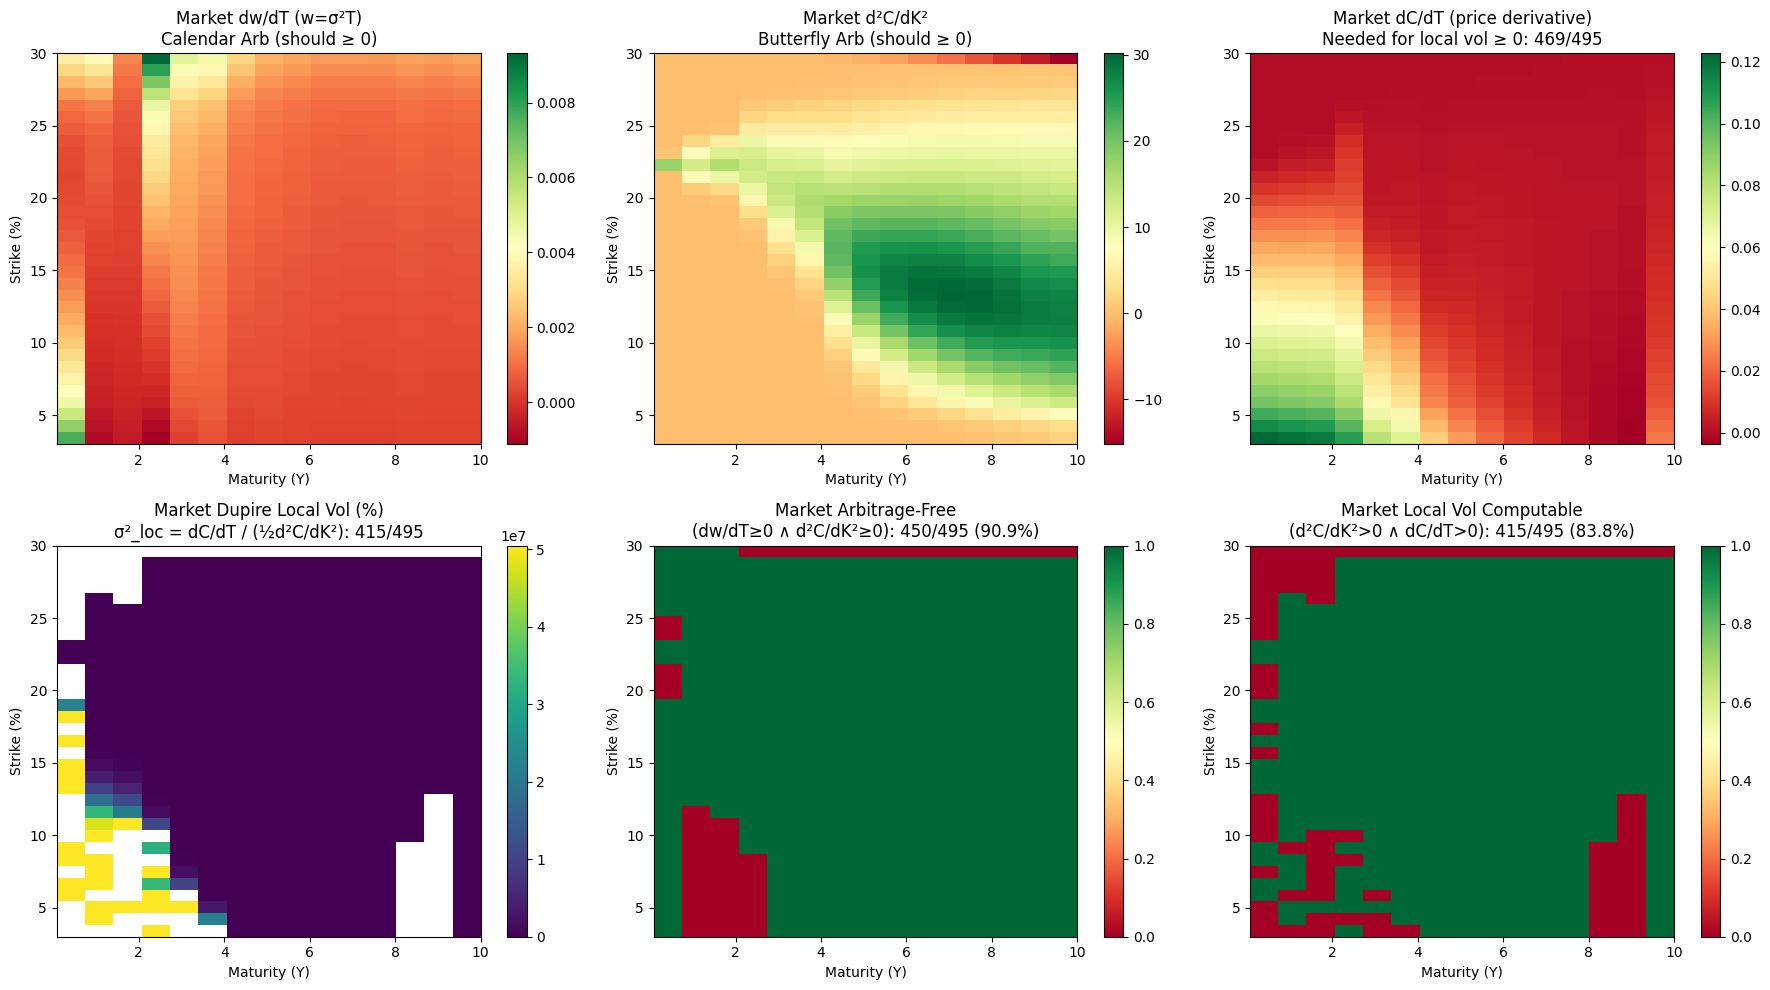


Market surface arbitrage-free: False


In [10]:
# ── Market surface arbitrage check ──
arb_df, arb_summary = check_market_arbitrage(
    vol_key_rate, fwd_key_rate, fwd_ois,
    tau=0.25, h_T=0.1, h_K=0.005, plot=True, verbose=True
)
print(f"\nMarket surface arbitrage-free: {arb_summary['is_arbitrage_free']}")

c:\Personal\Education\MSc - PHDs\MIPT\Final paper\noa\docs\quant\ap\multi_theta\../..\ap\caplet_vol_surface.py:491: RuntimeWarning: invalid value encountered in sqrt
  local_vol_matrix = np.where(local_var_matrix > 0, np.sqrt(local_var_matrix) * 100, np.nan)


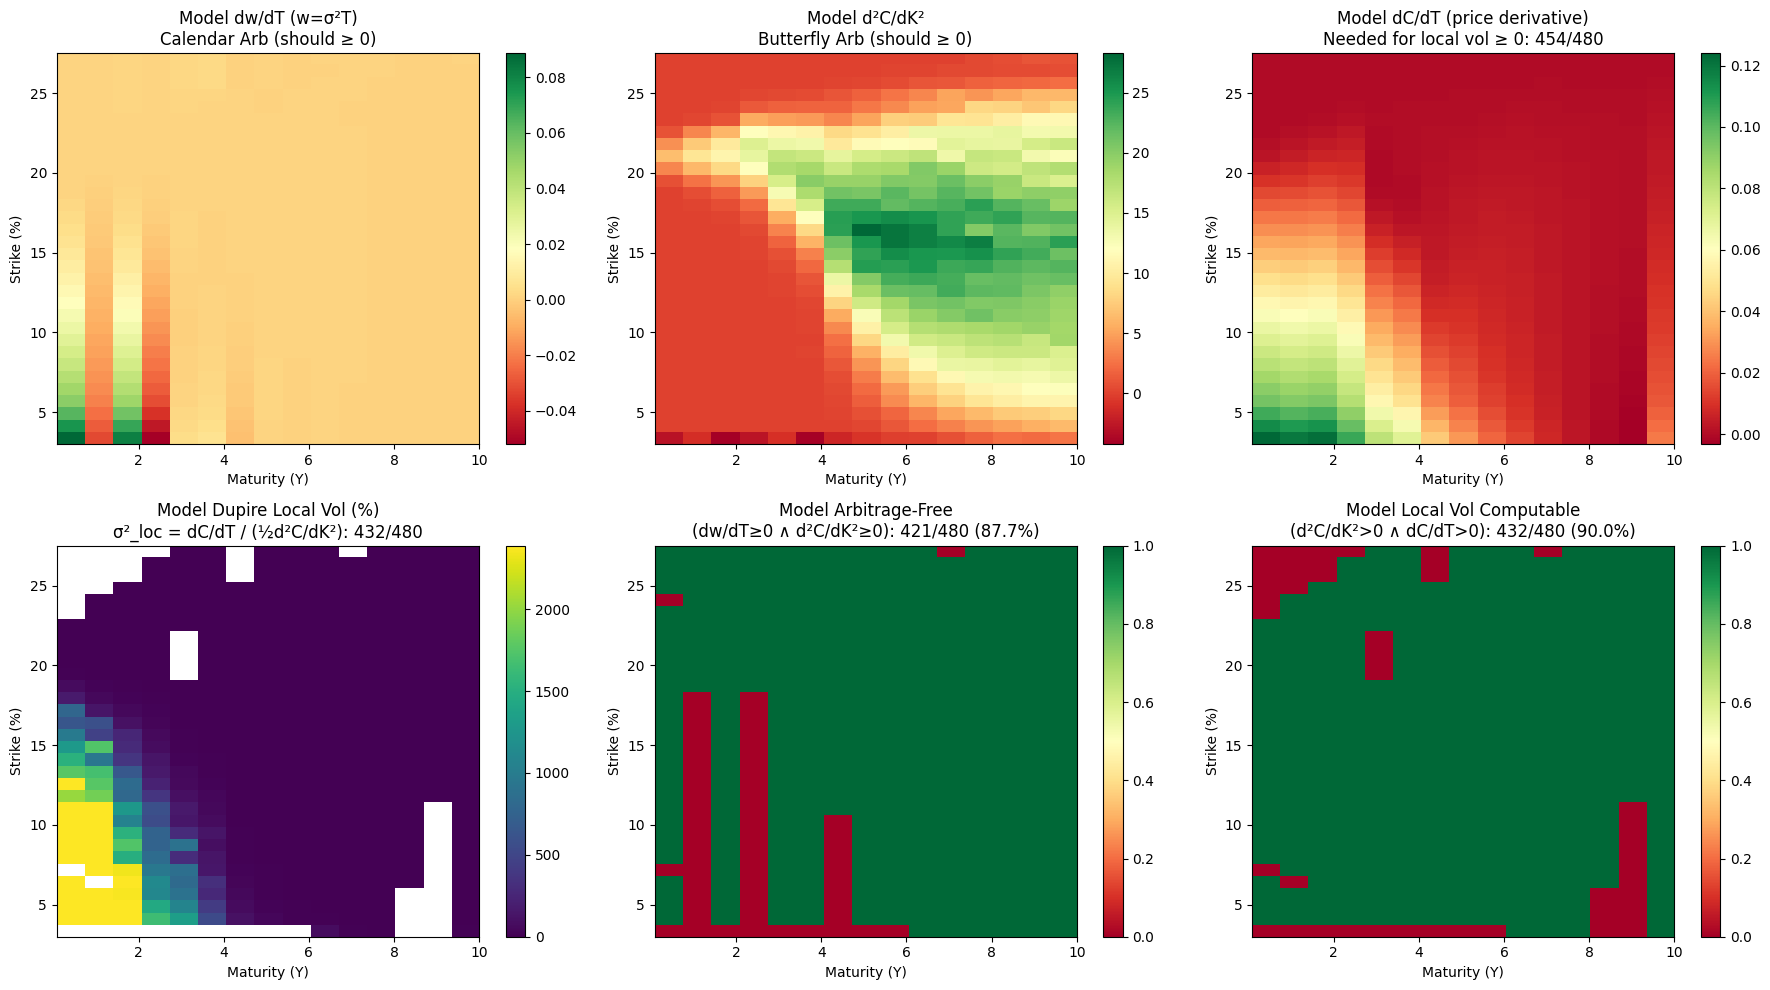

Model arbitrage-free: False


In [11]:
# ── Model surface arbitrage check ──
model_vol_df = vol_results[['time_to_maturity', 'strike']].copy()
model_vol_df['implied_normal_vol'] = vol_results[mcol]
model_vol_df = model_vol_df.dropna(subset=['implied_normal_vol'])

_, model_arb = check_market_arbitrage(
    model_vol_df, fwd_key_rate, fwd_ois,
    tau=0.25, h_T=0.1, h_K=0.005, plot=True, verbose=False, surface_name="Model"
)
print(f"Model arbitrage-free: {model_arb['is_arbitrage_free']}")